# 1. Import and Hardware Setup

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, datasets
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

!pip install tqdm -q
from tqdm.auto import tqdm

# Set device to GPU, MPS, or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(f"Using device: {device}")

Using device: cuda


In [45]:
DATA_PATH = './Data'

# 2. Hyperparameter

In [46]:
BATCH_SIZE = 256
IMG_SIZE = 32
LR = 1e-3
EPOCHS = 200
LATENT_DIM = 256
IN_CHANNELS = 3
ENCODER_CHANNELS = [32, 64, 128, 256]

# 3. Data Preparation

In [48]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

train_dataset = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=8,
    persistent_workers=True,
    prefetch_factor=10,
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=8,
    persistent_workers=True,
    prefetch_factor=10,
)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


# 4. Model Architecture

In [49]:
class ConvBA(nn.Sequential):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=2,  # to reduce the resolution
        padding=1,
    ):
        super().__init__(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )


class ConvTransBA(nn.Sequential):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=2,
        padding=1,
        output_padding=1,
    ):
        super().__init__(
            nn.ConvTranspose2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                output_padding=output_padding,
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )


class Autoencoder(nn.Module):
    def __init__(self, in_channels, img_size, encoder_channels, latent_dim):
        super().__init__()

        num_layers = len(encoder_channels)

        # The resolution of feature map after decoder
        final_h = img_size // (2**num_layers)
        final_w = img_size // (2**num_layers)

        # Check, if the
        assert final_h >= 1 and final_w >= 1, "Too much downsamplings"

        # -------------- Encoder --------------
        encoder_layers = []
        curr_channels = in_channels

        for out_channels in encoder_channels:
            encoder_layers.append(ConvBA(curr_channels, out_channels))
            curr_channels = out_channels

        encoder_layers.extend(
            [nn.Flatten(), nn.Linear(curr_channels * final_h * final_w, latent_dim)]
        )
        self.encoder = nn.Sequential(*encoder_layers)

        # -------------- Decoder --------------
        decoder_layers = []
        decoder_layers.extend(
            [
                nn.Linear(latent_dim, curr_channels * final_h * final_w),
                nn.Unflatten(1, (curr_channels, final_h, final_w)),
            ]
        )

        rev_channels = list(reversed(encoder_channels))
        for i in range(len(rev_channels) - 1):
            curr_channels = rev_channels[i]
            out_channels = rev_channels[i + 1]
            decoder_layers.append(ConvTransBA(curr_channels, out_channels))

        decoder_layers.extend(
            [
                nn.ConvTranspose2d(
                    in_channels=rev_channels[-1],
                    out_channels=in_channels,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1,
                ),
                nn.Sigmoid(),
            ]
        )

        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        latent = self.encoder(x)
        return self.decoder(latent)

In [50]:
model = Autoencoder(
    in_channels=IN_CHANNELS,
    img_size=IMG_SIZE,
    encoder_channels=ENCODER_CHANNELS,
    latent_dim=LATENT_DIM,
).to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters()) / 1e6):.2f}M")

Total parameters: 1.30M


# 5. Train

In [51]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5)

In [52]:
def train(model, loader, criterion, optimizer):
    model.train()
    train_loss = 0.0
    loop = tqdm(loader, desc="Training", leave=False)
    
    for images, _ in loop:
        images = images.to(device)
        optimizer.zero_grad(set_to_none=True)
        
        recontructed = model(images)
        loss = criterion(recontructed, images)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.detach() * images.size(0)
    return train_loss.item() / len(loader.dataset)

In [53]:
train_losses = []

for epoch in range(EPOCHS):
    train_loss = train(model, train_loader, criterion, optimizer)
    scheduler.step(train_loss)
    
    train_losses.append(train_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}: Loss: {train_loss:.6f}")

Training:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 1/200: Loss: 0.021425


Training:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 2/200: Loss: 0.009957


Training:   0%|          | 0/196 [00:00<?, ?it/s]

...

Epoch 198/200: Loss: 0.002277


Training:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 199/200: Loss: 0.002271


Training:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 200/200: Loss: 0.002274


# 6. Result Visualization

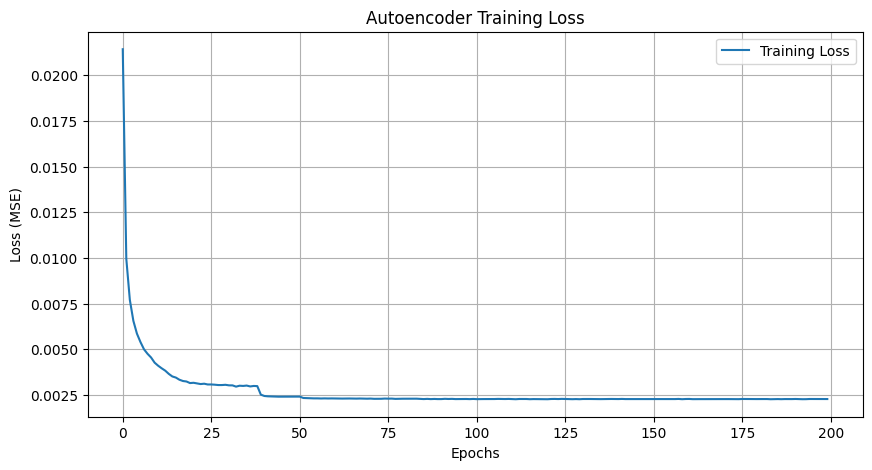

In [54]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Visualizing original vs reconstructed images...


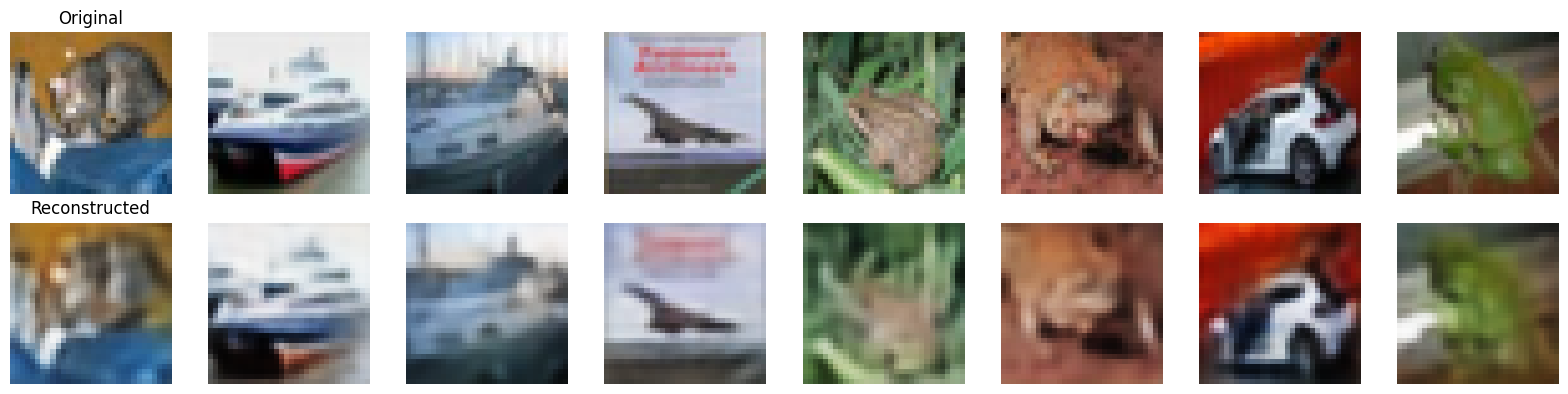

In [55]:
# Evaluation and Visualization
def visualize_reconstruction(model, test_loader, num_images=8):
    model.eval()
    
    # Get a batch of test images
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    images = images.to(device)
    
    with torch.no_grad():
        reconstructed = model(images)
        
    # Move images to CPU for visualization
    images = images.cpu()
    reconstructed = reconstructed.cpu()
    
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))
    for i in range(num_images):
        # Original Image
        ax = axes[0, i]
        img = np.transpose(images[i].numpy(), (1, 2, 0))
        ax.imshow(img)
        ax.axis('off')
        if i == 0:
            ax.set_title("Original")
            
        # Reconstructed Image
        ax = axes[1, i]
        recon_img = np.transpose(reconstructed[i].numpy(), (1, 2, 0))
        ax.imshow(recon_img)
        ax.axis('off')
        if i == 0:
            ax.set_title("Reconstructed")
            
    plt.tight_layout()
    plt.show()

# Show results
print("Visualizing original vs reconstructed images...")
visualize_reconstruction(model, test_loader, num_images=8)